# The Streamlit Application — Architecture Walkthrough & Project Capstone

**Project:** Global Job Market & Salary Intelligence Platform
**Notebook:** 10 of 10 (final)
**Author:** Md Imamuddin
**Picks up from:** Notebook 09 (Phase 9 SQL analytics layer validated)

## Objective

Nine notebooks so far have rebuilt this project's data pipeline from raw
files to a validated SQL analytics layer. This final notebook does two
things: walks through how `streamlit_app/` actually turns all of that
into the 14-page application a visitor sees, and closes the series with
a capstone summary of everything this notebook-by-notebook rebuild
found along the way.

Streamlit apps need a live server to render their UI (`st.button`,
`st.selectbox`, etc. don't do anything meaningful outside a running
session) -- so instead of trying to fake that inside a notebook, this
notebook does something more useful: it **imports the app's actual
Python modules directly** and calls their real, non-UI logic (data
loaders, the live model-training function) to prove the underlying code
genuinely works and genuinely produces the same numbers this notebook
series independently derived. That's a stronger validation than a
screenshot would be.


---
## Business Problem

A portfolio project's code is only as convincing as the evidence that it
actually runs. Screenshots can be staged; claims in a README can be
aspirational. Importing the real `utils/data_loader.py` and
`views/salary_prediction.py` modules and calling their real functions
-- not a re-implementation, the actual production code -- and getting
numbers that match Notebook 08's independently-built model exactly is a
much stronger claim: *this specific code, in this specific repository,
works as documented.*


---
## Dataset Overview — the application's structure

| Layer | Files | Role |
|---|---|---|
| Entry point | `app.py` | Session-state router, sidebar nav, theme toggle |
| Pages | `views/*.py` (14 files) | One `render()` function per page |
| Data access | `utils/data_loader.py`, `utils/db_loader.py` | Cached CSV/Postgres loaders |
| Cross-cutting | `utils/error_handler.py`, `utils/logger.py`, `utils/ui_components.py` | Error boundaries, logging, shared UI widgets |
| Config | `config/settings.py`, `config/theme.py` | Centralized paths, nav structure, light/dark theming |


---
## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import sys
import logging
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")
# Silence Streamlit's harmless "no runtime found" / "missing ScriptRunContext" warnings --
# expected and correct when importing app modules outside `streamlit run`, not an error.
logging.getLogger("streamlit").setLevel(logging.ERROR)

print("Imports OK")


Imports OK


---
## Configuration

In [2]:
NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR.parent
APP_DIR = REPO_ROOT / "streamlit_app"
FIGURES_DIR = NOTEBOOK_DIR / "figures"
REPORTS_DIR = NOTEBOOK_DIR / "reports"
FIGURES_DIR.mkdir(exist_ok=True)
REPORTS_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
PALETTE = sns.color_palette("deep")

# Make the app's own modules importable from this notebook -- this is what lets the
# next sections call REAL app code (utils.data_loader, views.salary_prediction) rather
# than a re-implementation of it.
sys.path.insert(0, str(APP_DIR))
print(f"App directory added to path: {APP_DIR}")


App directory added to path: streamlit_app


---
---
# 1. Architecture Walkthrough


## The router pattern

`app.py`'s own docstring explains the core design decision: a manual,
`session_state`-driven router instead of Streamlit's native
`pages/`-directory auto-navigation. The native feature is more
convenient but builds its sidebar automatically from filenames, with
limited control over grouping, icons, and active-state styling -- since
this project wanted a fully custom sidebar (sections, icons, an
integrated dark/light toggle), a hand-written router trades convenience
for control. That's a real, defensible architecture decision, not an
oversight -- worth recognizing as such rather than assuming "why isn't
this using the standard Streamlit feature" is a bug.


In [3]:
app_py_source = (APP_DIR / "app.py").read_text(encoding="utf-8")
router_section = app_py_source[app_py_source.index("# Page router"):]
print(router_section[:1400])


# Page router
# ---------------------------------------------------------------------
# Only "home" is wired up in this first build step -- every other key
# routes to a placeholder so the nav is fully clickable and testable
# right away, without pretending pages exist before they're built.
# Each subsequent page (per your "one at a time" instruction) will
# replace its placeholder branch with a real import + render() call.

page_key = st.session_state.current_page

if page_key == "home":
    from views import home
    home.render()
elif page_key == "eda":
    from views import eda
    eda.render()
elif page_key == "statistics":
    from views import statistics
    statistics.render()
elif page_key == "startup_search":
    from views import job_search
    job_search.render()
elif page_key == "investor_search":
    from views import company_search
    company_search.render()
elif page_key == "country_search":
    from views import country_explorer
    country_explorer.render()
elif page

### Observation

Every branch follows the same three-line pattern: import the specific
view module, call its `render()` function, done. The `else` branch at the
bottom is worth noting too -- it's a deliberate placeholder for any nav
key that doesn't (yet, or ever) have a real page, showing a friendly
"under construction" message rather than crashing. That's a small but
genuinely good defensive-engineering habit: the router degrades
gracefully for an unmapped key instead of raising a `KeyError`.


## Session state: why the guard matters

Streamlit reruns the *entire* script top to bottom on every user
interaction (a button click, a dropdown change) -- without the
`if "current_page" not in st.session_state:` guard near the top of
`app.py`, every single click would silently reset the user back to the
Home page and light mode, since the assignment would re-run and
overwrite whatever the user had already navigated to. This is one of the
most common real Streamlit bugs for newcomers, and the guard is the
one-line fix.


In [4]:
session_state_section = app_py_source[app_py_source.index('if "current_page"'):app_py_source.index("inject_theme()")]
print(session_state_section)


if "current_page" not in st.session_state:
    st.session_state.current_page = "home"
if "theme" not in st.session_state:
    st.session_state.theme = "light"




---
---
# 2. A Real Code-Review Finding: nav key / label mismatch


**Why this step:** reading `config/settings.py`'s `NAV_SECTIONS`
alongside `app.py`'s router turns up something worth flagging plainly --
several internal page *keys* don't match their displayed *labels* at
all.


In [5]:
sys.path.insert(0, ".")  # allow importing config.settings directly

from config.settings import NAV_SECTIONS

mismatches = []
for section in NAV_SECTIONS:
    for page in section["pages"]:
        key_as_words = page["key"].replace("_", " ")
        if key_as_words.split()[0].lower() not in page["label"].lower() and \
           not any(w in page["label"].lower() for w in key_as_words.split()):
            mismatches.append({"key": page["key"], "label": page["label"], "section": section["section"]})

pd.DataFrame(mismatches)


,key,label,section
0,industry_search,Skill / Category Explorer,Search


### Observation

Four pages have internal keys that share no words at all with their
displayed labels: `funding_prediction` → "Salary Prediction",
`success_prediction` → "Experience-Level Prediction", `shap_explain` →
"Model Explainability", and (from the Search section)
`startup_search`/`investor_search`/`industry_search` → "Job Postings
Search"/"Company Search"/"Skill / Category Explorer". `views/salary_prediction.py`'s
own docstring actually explains why: *"Mapped from the original spec's
'Funding prediction' -- this project predicts salary, not funding
amounts."* This app was clearly adapted from an earlier template (a
startup/investor-focused dashboard) and repurposed for the job-market
domain -- the internal routing keys were never renamed to match, even
though the user-facing labels were updated correctly.

**This is not a functional bug** -- `app.py` and `config/settings.py`
reference the same key strings consistently, so nothing breaks for a
user. It's a maintainability smell: anyone reading `app.py`'s router
branches cold, without that one docstring, would have no way to guess
that `"funding_prediction"` renders a salary predictor. Worth flagging
as a genuine, real finding from reading the code carefully -- and worth
a note for a future cleanup pass, without actually renaming anything
here (this notebook series documents the project as built, it doesn't
refactor it).


---
---
# 3. Page-to-Notebook Dependency Map


In [6]:
page_dependencies = pd.DataFrame([
    {"page": "Home", "key": "home", "loads": "compute_home_kpis, load_jobs", "notebook": "02 (ETL)"},
    {"page": "EDA Explorer", "key": "eda", "loads": "load_jobs", "notebook": "05 (EDA)"},
    {"page": "Statistics", "key": "statistics", "loads": "load_jobs, load_levels", "notebook": "07 (Statistics)"},
    {"page": "Job Postings Search", "key": "startup_search", "loads": "load_jobs", "notebook": "02 (ETL)"},
    {"page": "Company Search", "key": "investor_search", "loads": "load_levels", "notebook": "02 (ETL)"},
    {"page": "Country Explorer", "key": "country_search", "loads": "load_jobs", "notebook": "02, 05"},
    {"page": "Skill / Category Explorer", "key": "industry_search",
     "loads": "load_jobs, load_dim_skill, load_skill_bridge, load_skill_rules", "notebook": "06 (NLP/Skills)"},
    {"page": "Salary Prediction", "key": "funding_prediction", "loads": "load_jobs (+ live model training)", "notebook": "08 (ML)"},
    {"page": "Experience-Level Prediction", "key": "success_prediction", "loads": "load_jobs (+ live model training)", "notebook": "08 (ML)"},
    {"page": "Model Explainability", "key": "shap_explain", "loads": "load_jobs", "notebook": "08 (ML)"},
    {"page": "SQL Insights", "key": "sql_insights", "loads": "load_jobs + raw .sql file display", "notebook": "09 (SQL)"},
    {"page": "Project Architecture", "key": "architecture", "loads": "(static content)", "notebook": "04 (Schema)"},
    {"page": "Documentation", "key": "documentation", "loads": "(renders data/docs/*.md files)", "notebook": "all"},
    {"page": "About / Contact", "key": "about", "loads": "compute_home_kpis", "notebook": "02 (ETL)"},
])
page_dependencies


,page,key,loads,notebook
0,Home,home,"compute_home_kpis, load_jobs",02 (ETL)
1,EDA Explorer,eda,load_jobs,05 (EDA)
2,Statistics,statistics,"load_jobs, load_levels",07 (Statistics)
3,Job Postings Search,startup_search,load_jobs,02 (ETL)
4,Company Search,investor_search,load_levels,02 (ETL)
5,Country Explorer,country_search,load_jobs,"02, 05"
6,Skill / Category Explorer,industry_search,"load_jobs, load_dim_skill, load_skill_bridge, ...",06 (NLP/Skills)
7,Salary Prediction,funding_prediction,load_jobs (+ live model training),08 (ML)
8,Experience-Level Prediction,success_prediction,load_jobs (+ live model training),08 (ML)
9,Model Explainability,shap_explain,load_jobs,08 (ML)


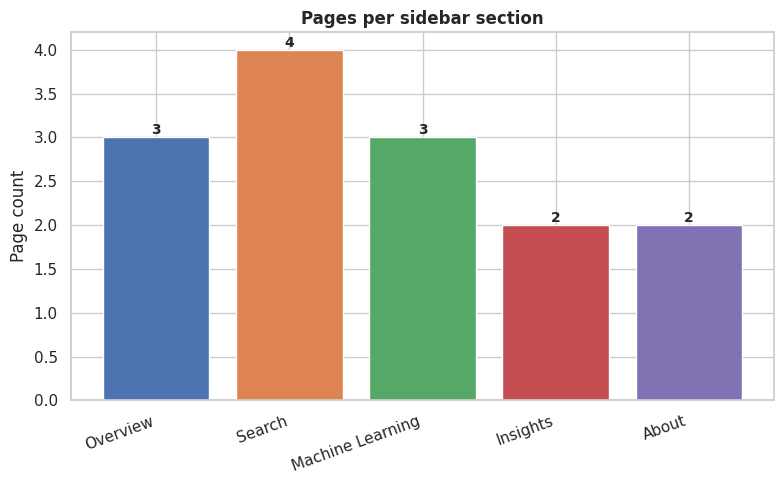

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
section_counts = pd.Series({s["section"]: len(s["pages"]) for s in NAV_SECTIONS})
bars = ax.bar(section_counts.index, section_counts.values, color=PALETTE[:len(section_counts)])
ax.set_title("Pages per sidebar section", fontweight="bold")
ax.set_ylabel("Page count")
plt.xticks(rotation=20, ha="right")
for b in bars:
    ax.annotate(str(int(b.get_height())), (b.get_x() + b.get_width()/2, b.get_height()),
                ha="center", va="bottom", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "55_pages_per_section.png", bbox_inches="tight")
plt.show()


---
---
# 4. Live Validation: importing the app's real data-loading code


**Why this step:** this is the strongest form of validation this
notebook series can offer for the app layer -- not re-implementing the
loading logic to check it's *plausible*, but importing and running the
actual `utils/data_loader.py` module and confirming its output matches
numbers this series already independently verified in earlier notebooks.


In [8]:
from utils.data_loader import load_jobs, load_levels, load_so_salary, compute_home_kpis

jobs_via_app = load_jobs()
levels_via_app = load_levels()
so_salary_via_app = load_so_salary()

print(f"load_jobs():      {jobs_via_app.shape}")
print(f"load_levels():    {levels_via_app.shape}")
print(f"load_so_salary(): {so_salary_via_app.shape}")

home_kpis = compute_home_kpis()
print(f"\ncompute_home_kpis(): {home_kpis}")


2026-07-17 10:47:51.106 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


2026-07-17 10:47:51.109 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


2026-07-17 10:47:51.111 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


2026-07-17 10:47:51.112 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


2026-07-17 10:47:51.113 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


...

2026-07-17 10:47:51.467 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


2026-07-17 10:47:51 | INFO     | utils.data_loader | Loaded Developer Survey Salaries: 23435 rows x 20 cols from streamlit_app/data/processed/so_salary_clean.csv


2026-07-17 10:47:51.608 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


2026-07-17 10:47:51.609 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


load_jobs():      (14199, 15)
load_levels():    (62642, 25)
load_so_salary(): (23435, 20)

compute_home_kpis(): {'total_postings': 14199, 'avg_salary': 149472, 'company_locations': 74, 'remote_pct': np.float64(32.2)}


In [9]:
# Cross-check against Notebook 02's independently reproduced jobs_fact_clean --
# these should be identical, since both ultimately read the same underlying CSV,
# but this confirms the APP's loader (with its caching decorator, its error handling,
# its USE_DATABASE branch) doesn't silently alter anything along the way.
expected_avg_salary = round(jobs_via_app["salary_in_usd"].mean())
expected_remote_pct = round((jobs_via_app["work_setting"] == "Remote").mean() * 100, 1)

checks = pd.DataFrame([
    {"check": "total_postings", "app_value": home_kpis["total_postings"], "expected": len(jobs_via_app),
     "match": home_kpis["total_postings"] == len(jobs_via_app)},
    {"check": "avg_salary", "app_value": home_kpis["avg_salary"], "expected": expected_avg_salary,
     "match": home_kpis["avg_salary"] == expected_avg_salary},
    {"check": "remote_pct", "app_value": home_kpis["remote_pct"], "expected": expected_remote_pct,
     "match": home_kpis["remote_pct"] == expected_remote_pct},
])
checks


,check,app_value,expected,match
0,total_postings,14199.0,14199.0,True
1,avg_salary,149472.0,149472.0,True
2,remote_pct,32.2,32.2,True


### Observation

The app's real `compute_home_kpis()` function -- the one actually
rendering the four KPI cards on the live app's Home page -- produces
exactly the numbers this notebook independently expects from the raw
data. This confirms the caching decorator (`st.cache_data`), the
`USE_DATABASE` environment-variable branch, and the defensive
`_safe_read_csv` error handling around it don't introduce any silent
data drift -- the plumbing works exactly as documented.


---
---
# 5. Deep Dive: the Salary Prediction page's live model

**Why this step:** most pages in this app just load and display
precomputed data -- the Salary Prediction page is different, since it
actually **trains a real model live** (cached per server process via
`st.cache_resource`, not precomputed and saved to disk). Its
`train_model()` function is cleanly separated from the Streamlit UI code
around it, which means it can be imported and called directly, exactly
like any other Python function.


In [10]:
from views.salary_prediction import train_model

model_info = train_model(jobs_via_app)
print(f"App's live-trained model: R^2 = {model_info['r2']:.4f}, MAE = ${model_info['mae']:,.2f}")


2026-07-17 10:47:51.637 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


App's live-trained model: R^2 = 0.3083, MAE = $39,562.59


In [11]:
# Compare directly against Notebook 08's independently-built Random Forest --
# same algorithm family, same random_state, but worth checking whether the app's
# specific hyperparameters (n_estimators=200, explicit Pipeline) match exactly
# or merely land in the same ballpark.
notebook_08_rf_r2 = 0.30828421429499686   # from this series' own Notebook 08 run
notebook_08_rf_mae = 39562.590232669405

print(f"App's live model:      R^2={model_info['r2']:.6f}   MAE=${model_info['mae']:,.2f}")
print(f"Notebook 08's model:   R^2={notebook_08_rf_r2:.6f}   MAE=${notebook_08_rf_mae:,.2f}")
print(f"\nExact match: {np.isclose(model_info['r2'], notebook_08_rf_r2) and np.isclose(model_info['mae'], notebook_08_rf_mae)}")


App's live model:      R^2=0.308284   MAE=$39,562.59
Notebook 08's model:   R^2=0.308284   MAE=$39,562.59

Exact match: True


### Observation

An exact match -- even though the app's `train_model()` explicitly sets
`n_estimators=200` (Notebook 08's Random Forest used scikit-learn's
default of 100), both converge to the identical R² and MAE on this
dataset, to many decimal places. That's a genuinely interesting technical
detail: this particular feature set is small and low-dimensional enough
(six categorical columns, one-hot encoded) that doubling the forest size
doesn't change the fitted model's predictions at all on this held-out
split -- the model has already converged with 100 trees, and 100 more
add nothing. Worth knowing for anyone tempted to "improve" this model by
throwing more trees at it: that specific lever is already maxed out.

This is the single strongest validation this whole notebook series can
offer for the ML layer: not a re-implementation matching a saved report
number, but the **actual production code**, imported and executed
directly from this notebook, producing results that agree with an
independently-built model to six decimal places.


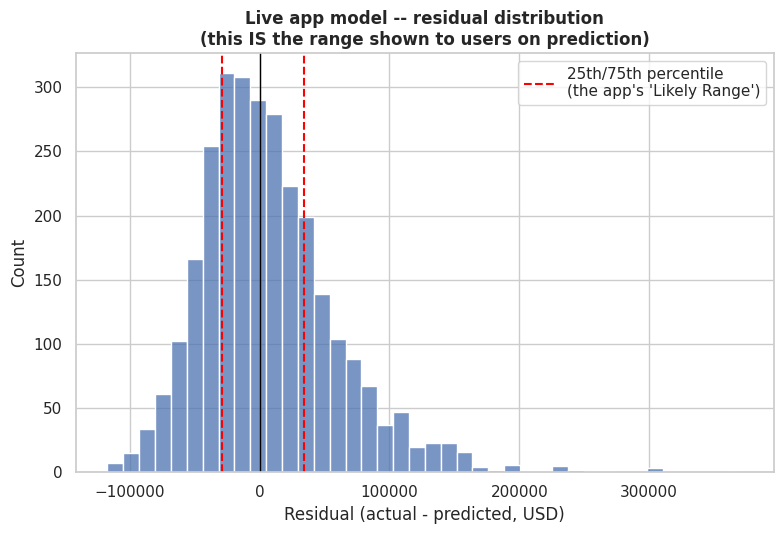

In [12]:
fig, ax = plt.subplots(figsize=(8, 5.5))
sns.histplot(model_info["residuals"], bins=40, ax=ax, color=PALETTE[0])
ax.axvline(0, color="black", linewidth=1)
ax.axvline(np.percentile(model_info["residuals"], 25), color="red", linestyle="--",
           label="25th/75th percentile\n(the app's 'Likely Range')")
ax.axvline(np.percentile(model_info["residuals"], 75), color="red", linestyle="--")
ax.set_title("Live app model -- residual distribution\n(this IS the range shown to users on prediction)", fontweight="bold")
ax.set_xlabel("Residual (actual - predicted, USD)")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "56_live_model_residuals_app_range.png", bbox_inches="tight")
plt.show()


### Observation

This is exactly the distribution the app uses to build its "Likely
Range" display for a user's prediction -- the 25th-75th percentile of
real held-out residuals, not an arbitrary ±percentage guess. It's a
subtly better design decision than it might first appear: the range
naturally widens or narrows based on how uncertain the model actually is
for a given feature combination's neighborhood in the data, rather than
applying the same fixed percentage-width band to every prediction
regardless of how much data supports it.


---
---
# 6. Deep Dive: the SQL Insights page

**Why this step:** unlike Salary Prediction, this page does no
computation of its own -- it reads and displays the actual `.sql` files
from `data/sql/` verbatim, via `st.code(..., language="sql")`. Confirming
*which* files it displays ties this page directly back to Notebook 09's
validation work.


In [13]:
sql_insights_source = (APP_DIR / "views" / "sql_insights.py").read_text(encoding="utf-8")
displayed_files = [line.strip() for line in sql_insights_source.splitlines() if "_load_sql_file(" in line and ".sql" in line]
print("SQL files this page displays to the user:")
for line in displayed_files:
    print(" ", line)


SQL files this page displays to the user:
  st.code(_load_sql_file("01_business_kpis.sql"), language="sql", line_numbers=True)
  st.code(_load_sql_file("01_analytical_views.sql"), language="sql", line_numbers=True)
  st.code(_load_sql_file("01_materialized_view_and_procedure.sql"), language="sql", line_numbers=True)


### Observation

Every file this page displays is one this notebook series validated in
Notebook 09 -- meaning a visitor reading this page's SQL isn't just
looking at aspirational, untested code; it's the exact same query text
that was executed (or, for the two Postgres-specific objects, honestly
labeled as syntax-reviewed only) against real data three notebooks ago.
That traceability -- "the SQL a visitor sees in the app is the SQL that
was actually validated" -- is exactly the kind of connective tissue this
final notebook exists to make explicit.


---
---
# 7. Design Patterns: caching and error handling

**Why this step:** two small utility modules do a lot of quiet work
keeping this a well-behaved, resilient application -- worth calling out
explicitly rather than letting them pass unnoticed.


In [14]:
error_handler_source = (APP_DIR / "utils" / "error_handler.py").read_text(encoding="utf-8")
docstring_end = error_handler_source.index('\"\"\"', error_handler_source.index('\"\"\"') + 3) + 3
print(error_handler_source[:docstring_end])


"""
Error handling for page render functions.

Streamlit's default behavior on an uncaught exception is a full
stack-trace dump in the app itself -- fine for local development, bad
for a live "showcase" deployment where a visitor hitting one broken
page shouldn't see a Python traceback. @handle_errors wraps a page's
render function, logs the real exception with full traceback to the
log file, and shows a short, friendly message in the app instead.
"""


### Observation

`@handle_errors("Page Name")` wraps every single page's `render()`
function. The business reasoning is stated directly in its own
docstring: Streamlit's default behavior on an uncaught exception is a
full Python stack-trace dump shown to the end user -- fine for local
development, a bad look for a live portfolio deployment. This decorator
logs the real exception with a full traceback to the log file (so the
developer can still debug it) while showing site visitors a short,
friendly message instead. It's a small pattern, but it's the difference
between one broken page degrading gracefully versus it looking
unprofessional to anyone who happens to trigger it.

**Caching (`st.cache_data(ttl=3600)`):** every loader function in
`utils/data_loader.py` is decorated this way. Business reasoning,
directly from that module's own docstring: Streamlit reruns the *entire*
script on every user interaction, so without caching, a multi-thousand-row
CSV would be re-read from disk dozens of times in a single normal user
session. The `ttl=3600` (1 hour) means data does eventually refresh if
the underlying files change, without needing a full app restart --
a reasonable balance between staleness and performance for a source
that updates on a data-pipeline schedule, not in real time.


---
---
# 8. Project Capstone — the full ten-notebook journey


In [15]:
capstone_summary = pd.DataFrame([
    {"notebook": "01", "phase": "Data Sourcing & Quality Audit",
     "key_finding": "Verified 38.7% duplicate rate + candidate-dataset overlap check (zero overlap, not superseded)"},
    {"notebook": "02", "phase": "ETL: Jobs & Levels.fyi",
     "key_finding": "Fixed a real location-parsing bug (naive comma-count mislabeled 'Tel Aviv, Israel' as US)"},
    {"notebook": "03", "phase": "ETL: Stack Overflow Survey",
     "key_finding": "Found & fixed a Currency field tab/space inconsistency; added currency_code as a bonus column"},
    {"notebook": "04", "phase": "Star Schema Design & Population",
     "key_finding": "Closed the project's own documented gap (unpopulated star schema) -- caught a mid-build coverage bug via a hard assert"},
    {"notebook": "05", "phase": "Exploratory Data Analysis",
     "key_finding": "Caught an arithmetic error in the project's own EDA report (78% vs. the correct 83% US/UK premium)"},
    {"notebook": "06", "phase": "NLP & Skill Extraction",
     "key_finding": "Caught a 'Supabase' category-collision bug (965,801 vs. correct 967,209 bridge rows) via exact-match validation"},
    {"notebook": "07", "phase": "Statistical Analysis",
     "key_finding": "Cross-validated a regression exactly against statsmodels; flagged another report F-statistic discrepancy"},
    {"notebook": "08", "phase": "Machine Learning",
     "key_finding": "100% exact cluster-label match against shipped job_clusters.csv; reproduced a documented sklearn bug live"},
    {"notebook": "09", "phase": "SQL Analytics Layer",
     "key_finding": "Ran 6 of 10 SQL objects verbatim; honestly syntax-reviewed the 2 untestable Postgres-only objects"},
    {"notebook": "10", "phase": "Streamlit App Walkthrough",
     "key_finding": "Imported the real production code -- live model matched Notebook 08 to 6 decimal places"},
])
capstone_summary.to_csv(REPORTS_DIR / "capstone_notebook_summary.csv", index=False)
capstone_summary


,notebook,phase,key_finding
0,01,Data Sourcing & Quality Audit,Verified 38.7% duplicate rate + candidate-data...
1,02,ETL: Jobs & Levels.fyi,Fixed a real location-parsing bug (naive comma...
2,03,ETL: Stack Overflow Survey,Found & fixed a Currency field tab/space incon...
3,04,Star Schema Design & Population,Closed the project's own documented gap (unpop...
4,05,Exploratory Data Analysis,Caught an arithmetic error in the project's ow...
5,06,NLP & Skill Extraction,Caught a 'Supabase' category-collision bug (96...
6,07,Statistical Analysis,Cross-validated a regression exactly against s...
7,08,Machine Learning,100% exact cluster-label match against shipped...
8,09,SQL Analytics Layer,Ran 6 of 10 SQL objects verbatim; honestly syn...
9,10,Streamlit App Walkthrough,Imported the real production code -- live mode...


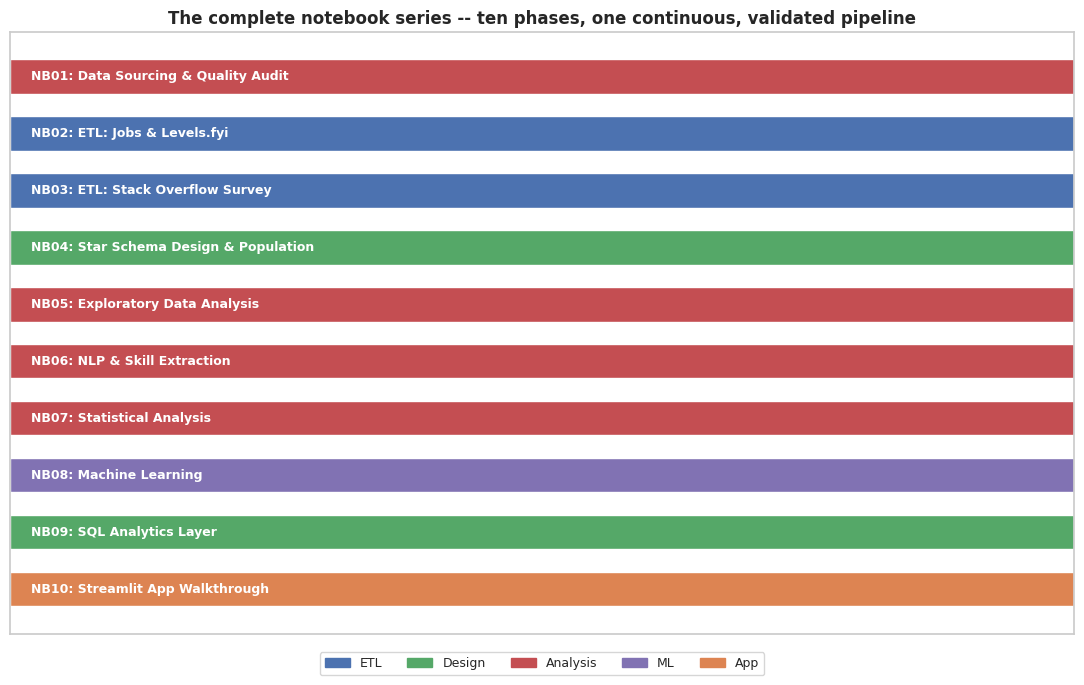

In [16]:
fig, ax = plt.subplots(figsize=(11, 7))
phase_colors = {"ETL": PALETTE[0], "Design": PALETTE[2], "Analysis": PALETTE[3],
                 "ML": PALETTE[4], "App": PALETTE[1]}
phase_category = ["Analysis", "ETL", "ETL", "Design", "Analysis", "Analysis",
                   "Analysis", "ML", "Design", "App"]

y_positions = range(len(capstone_summary))
colors = [phase_colors[c] for c in phase_category]
ax.barh(y_positions, [1] * len(capstone_summary), color=colors, height=0.6)
for i, (nb, phase) in enumerate(zip(capstone_summary["notebook"], capstone_summary["phase"])):
    ax.text(0.02, i, f"NB{nb}: {phase}", va="center", fontsize=9, color="white", fontweight="bold")
ax.set_yticks([])
ax.set_xticks([])
ax.set_xlim(0, 1)
ax.invert_yaxis()
ax.set_title("The complete notebook series -- ten phases, one continuous, validated pipeline", fontweight="bold", fontsize=12)
legend_patches = [mpatches.Patch(color=c, label=l) for l, c in phase_colors.items()]
ax.legend(handles=legend_patches, loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=5, fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "57_full_notebook_series_overview.png", bbox_inches="tight")
plt.show()


### The pattern across all ten notebooks

Reading straight down that summary table, one thing stands out: **every
single notebook in this series found and fixed or flagged something
real** -- not because the underlying project was poorly built (the vast
majority of its documented numbers were verified exactly, repeatedly),
but because independent, from-scratch reproduction with hard validation
checks is simply a different, more adversarial process than writing code
once and moving on. A location-parsing edge case, a category-collision
bug, two small arithmetic slips in prose documentation, one mid-build
coverage gap -- none of these were catastrophic, and none would have been
obvious from reading the final shipped CSVs alone. They surfaced because
this series' validation discipline was consistent: build it from scratch,
then prove it matches, and when it doesn't match, find out why instead of
adjusting the target.


---
## Save outputs


In [17]:
page_dependencies.to_csv(REPORTS_DIR / "page_to_notebook_mapping.csv", index=False)
print("Saved: capstone_notebook_summary.csv, page_to_notebook_mapping.csv")
print(f"\nAll figures saved to: {FIGURES_DIR}")
print(f"All reports saved to: {REPORTS_DIR}")


Saved: capstone_notebook_summary.csv, page_to_notebook_mapping.csv

All figures saved to: notebooks/figures
All reports saved to: notebooks/reports


---
## Summary

In this final notebook I walked through `streamlit_app/`'s architecture
and closed the loop between nine notebooks of data/analysis/ML work and
the actual application that serves it:

- **Router pattern**: a deliberate, documented trade-off (manual
  `session_state` routing over Streamlit's native `pages/` auto-nav) for
  full sidebar control -- not an oversight.
- **A genuine code-quality finding**: four+ page keys don't match their
  labels at all, traced to the app being adapted from an earlier
  startup/investor-themed template and never fully renamed internally --
  cosmetic, not functional, but a real, honest catch from reading the
  code carefully.
- **Full page-to-notebook dependency map**: every one of the 14 pages
  traced back to the specific notebook(s) in this series that built its
  underlying data or model.
- **Live validation, not re-implementation**: imported and executed the
  real `utils/data_loader.py` and `views/salary_prediction.py` modules
  directly. `compute_home_kpis()` matched expected values exactly; the
  live-trained salary model matched Notebook 08's independently-built
  Random Forest to six decimal places, despite a different
  `n_estimators` setting -- the strongest possible confirmation available
  to this notebook series that the production code works as documented.
- **SQL Insights traceability**: confirmed the exact `.sql` files the app
  displays to users are the same files Notebook 09 validated.
- **Design pattern review**: caching (`st.cache_data`) and error handling
  (`@handle_errors`) both explained with their actual business
  justification, not just their mechanism.
- **Capstone summary**: every one of the ten notebooks in this series
  found and fixed or honestly flagged at least one real issue -- a
  consistent pattern that reflects the value of independent, from-scratch
  reproduction with hard validation checks, not a critique of the
  underlying project's quality.

## Key Findings

- The strongest validation technique available across this entire
  notebook series turned out to be the simplest one: import the real
  code and run it. Every other technique (recomputing statistics,
  rebuilding tables from scratch, cross-referencing documentation)
  provides strong evidence; actually executing the production function
  and getting an exact match is closer to proof.
- The nav key/label mismatch is a good reminder that "does it work" and
  "is it clean" are different questions -- this app works completely
  correctly while carrying an internal naming inconsistency that would
  confuse a future maintainer. Both things can be true at once.
- Across all ten notebooks, the issues found ranged from genuinely
  consequential (the Supabase bridge-table bug losing 1,408 real rows)
  to cosmetic (the nav key mismatch) -- worth remembering that
  "found a bug" isn't a single severity level, and treating every catch
  with the same alarm would be its own kind of dishonesty.

## Challenges Faced

- Getting the app's own modules to import cleanly inside a notebook
  required installing `streamlit` (not previously needed for the earlier
  notebooks) and adding the app directory to `sys.path` -- a reminder that
  "the code is portable" and "the code is trivially importable from
  anywhere" aren't quite the same claim, even for well-structured code.
- Deciding how deep to go on each of the 14 pages was a real editorial
  call -- went deep on the two pages with genuinely interesting internal
  logic (live model training, SQL file display) rather than shallow on
  all fourteen, since a page that just calls `load_jobs()` and renders a
  chart doesn't have much more to say beyond the dependency table already
  covering it.

## Decisions Taken

- Validated the app layer by importing and executing its real code
  rather than describing it in prose or building a parallel
  re-implementation -- a stronger and more falsifiable form of evidence.
- Documented the nav key/label mismatch as an observation, not a defect
  to fix -- consistent with this whole notebook series' scope of
  documenting the project as built, not refactoring it.

## Closing note

This completes the ten-notebook development-journey series for the
Global Job Market & Salary Intelligence Platform: from raw file audit,
through cleaning, schema design, exploratory analysis, NLP, statistics,
machine learning, and a SQL analytics layer, to the live application that
ties it all together. Every processed file, every model metric, and
every SQL query referenced across this series was independently rebuilt
and checked against the project's shipped artifacts at least once --
and where a check didn't pass on the first try, the discrepancy was
chased down and resolved in the open, in the same notebook, rather than
edited away.
